In [ ]:
"""
First attempt at training the models. We used here for the label division 
NTSS < 3.5 - crypt < 50. 
The seed of the split is set to 42, while the random state for the shuffle of the cross validation is set to 8.

"""

'\nFirst attempt at training the models. We used here for the label division \n'

In [27]:
"""
=== PREZADO TEST SET ===
Selected papers (5):
  - FLASH Irradiation Results in Reduced Severe Skin Toxicity  (5 samples)
  - Design, Implementation, and in Vivo Validation of a Novel Proton FLASH Radiation Therapy System  (2 samples)
  - Effects of dose-rate on the radiation response of rat skin  (5 samples)
  - Long-term neurocognitive benefits of FLASH radiotherapy driven by reduced reactive oxygen species  (3 samples)
  - First demonstration of the FLASH effect with ultrahigh dose-rate high-energy X-rays  (3 samples)
Total samples in PREZADO test: 18

=== TOSCHINI TEST SET ===
Selected papers (1):
  - Levy et al., 2020  (2 samples)
Total samples in TOSCHINI test: 2

=== GLOBAL SPLIT SUMMARY ===
Original dataset size: 85
Train samples: 65
Test samples:  20
Excluded group 'Ruan et al., 2021' kept in TRAIN: 21 samples
Check: train + test = 85
"""

"\n=== PREZADO TEST SET ===\nSelected papers (5):\n  - FLASH Irradiation Results in Reduced Severe Skin Toxicity  (5 samples)\n  - Design, Implementation, and in Vivo Validation of a Novel Proton FLASH Radiation Therapy System  (2 samples)\n  - Effects of dose-rate on the radiation response of rat skin  (5 samples)\n  - Long-term neurocognitive benefits of FLASH radiotherapy driven by reduced reactive oxygen species  (3 samples)\n  - First demonstration of the FLASH effect with ultrahigh dose-rate high-energy X-rays  (3 samples)\nTotal samples in PREZADO test: 18\n\n=== TOSCHINI TEST SET ===\nSelected papers (1):\n  - Levy et al., 2020  (2 samples)\nTotal samples in TOSCHINI test: 2\n\n=== GLOBAL SPLIT SUMMARY ===\nOriginal dataset size: 85\nTrain samples: 65\nTest samples:  20\nExcluded group 'Ruan et al., 2021' kept in TRAIN: 21 samples\nCheck: train + test = 85\n"

In [28]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [29]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

test = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot_test.xlsx"
)

In [30]:
train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "augmented_3.xlsx"
)

In [31]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X_train = train[features]
y_train = train["Endpoint"]

X_test = test[features]
y_test = test["Endpoint"]

titles = train["Title"]

In [32]:
# RANDOM FOREST

In [33]:
from src.models.random_forest import train_random_forest
model = train_random_forest(X_train, y_train, n = 2000, msl = 10, mss = 20)

In [34]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model, X_train, y_train, titles)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  2
  Train samples: 160
  Test samples:  100

Fold 2:
  Train groups: 13
  Test groups:  3
  Train samples: 212
  Test samples:  48

Fold 3:
  Train groups: 12
  Test groups:  4
  Train samples: 224
  Test samples:  36

Fold 4:
  Train groups: 15
  Test groups:  1
  Train samples: 228
  Test samples:  32

Fold 5:
  Train groups: 10
  Test groups:  6
  Train samples: 216
  Test samples:  44



{'f1_scores': array([0.83211679, 0.8       , 0.76923077, 0.4       , 0.33333333]),
 'accuracy_scores': array([0.77      , 0.75      , 0.75      , 0.25      , 0.63636364]),
 'f1_mean': np.float64(0.626936178177054),
 'f1_std': np.float64(0.2144763760007861),
 'acc_mean': np.float64(0.6312727272727272),
 'acc_std': np.float64(0.19638350067875607)}

In [35]:
from src.models.evaluation import evaluate_model
evaluate_model(model, X_test, y_test)

{'accuracy': 0.6,
 'f1': 0.5555555555555556,
 'confusion_matrix': array([[7, 5],
        [3, 5]]),
 'fpr': array([0.        , 0.        , 0.        , 0.16666667, 0.16666667,
        0.33333333, 0.33333333, 0.58333333, 0.58333333, 0.66666667,
        0.66666667, 1.        , 1.        ]),
 'tpr': array([0.   , 0.125, 0.25 , 0.25 , 0.5  , 0.5  , 0.625, 0.625, 0.75 ,
        0.75 , 0.875, 0.875, 1.   ]),
 'roc_auc': 0.6354166666666667}

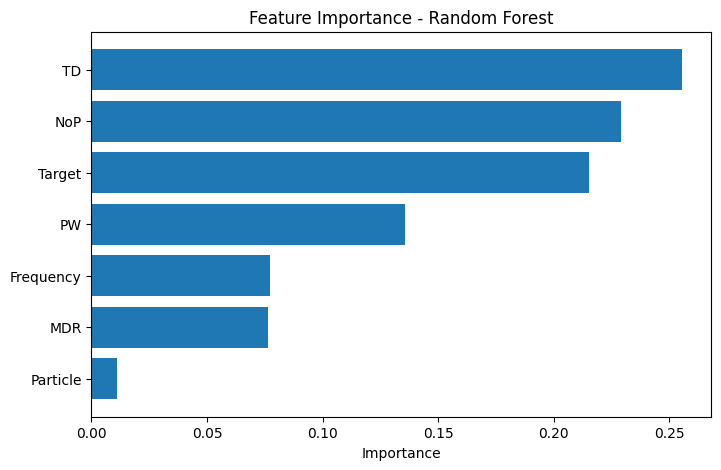

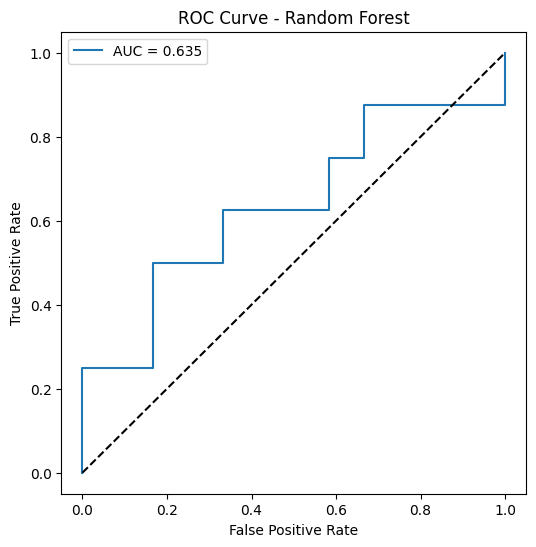

In [36]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance = get_feature_importance(model, features)
plot_feature_importance(feature_importance, "Random Forest")
plot_roc_curve(model, X_test, y_test, "Random Forest")

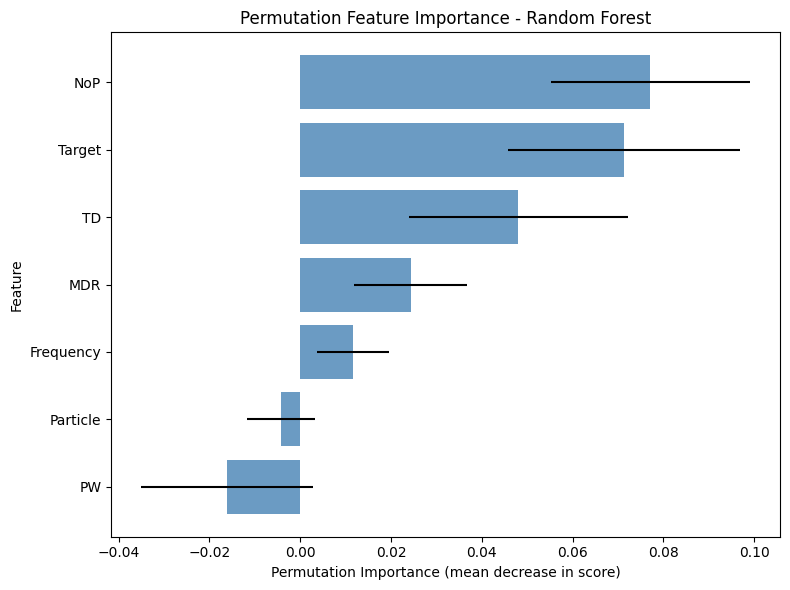

In [37]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="Random Forest"
)


In [38]:
# XGBOOST

In [39]:
from src.models.xgboost import train_xgb

model_xgb = train_xgb(X_train, y_train, n=500, md = 4, ra= 0.1, rl = 2)

In [40]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model_xgb, X_train, y_train, titles)


=== Fold composition summary ===

Fold 1:
  Train groups: 14
  Test groups:  2
  Train samples: 160
  Test samples:  100

Fold 2:
  Train groups: 13
  Test groups:  3
  Train samples: 212
  Test samples:  48

Fold 3:
  Train groups: 12
  Test groups:  4
  Train samples: 224
  Test samples:  36

Fold 4:
  Train groups: 15
  Test groups:  1
  Train samples: 228
  Test samples:  32

Fold 5:
  Train groups: 10
  Test groups:  6
  Train samples: 216
  Test samples:  44



{'f1_scores': array([0.73015873, 0.8       , 0.55      , 0.4       , 0.57142857]),
 'accuracy_scores': array([0.66      , 0.75      , 0.5       , 0.25      , 0.72727273]),
 'f1_mean': np.float64(0.6103174603174603),
 'f1_std': np.float64(0.1412270311449855),
 'acc_mean': np.float64(0.5774545454545456),
 'acc_std': np.float64(0.18561080760781806)}

In [41]:
from src.models.evaluation import evaluate_model
evaluate_model(model_xgb, X_test, y_test)

{'accuracy': 0.5,
 'f1': 0.5454545454545454,
 'confusion_matrix': array([[4, 8],
        [2, 6]]),
 'fpr': array([0.        , 0.        , 0.        , 0.33333333, 0.33333333,
        0.58333333, 0.58333333, 0.66666667, 0.66666667, 1.        ,
        1.        ]),
 'tpr': array([0.   , 0.125, 0.25 , 0.25 , 0.625, 0.625, 0.75 , 0.75 , 0.875,
        0.875, 1.   ]),
 'roc_auc': 0.59375}

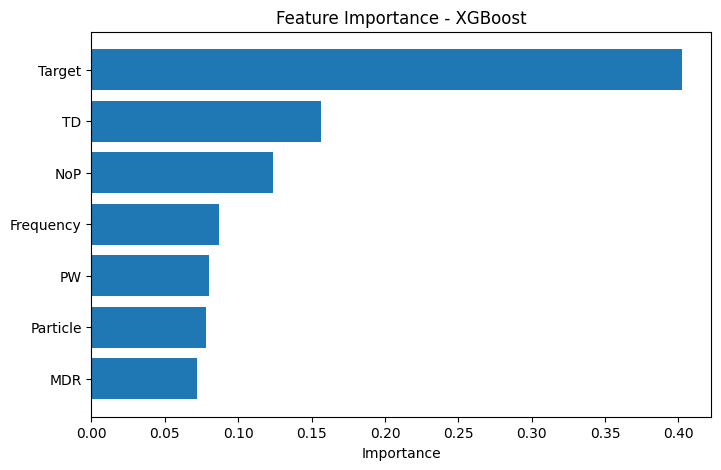

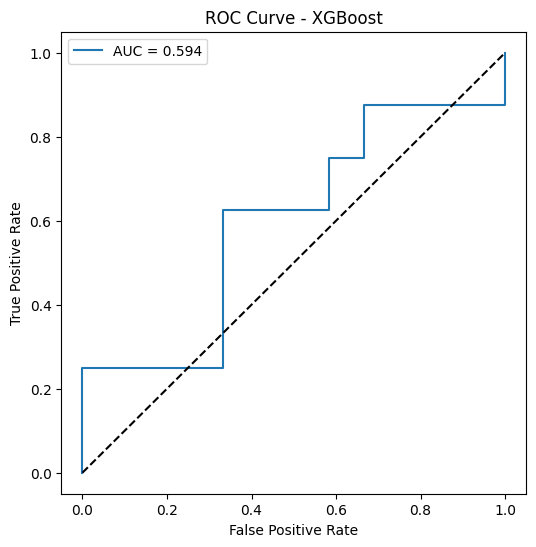

In [42]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance, plot_roc_curve

feature_importance_xgb = get_feature_importance(model_xgb, features)
plot_feature_importance(feature_importance_xgb, "XGBoost")
plot_roc_curve(model_xgb, X_test, y_test, "XGBoost")

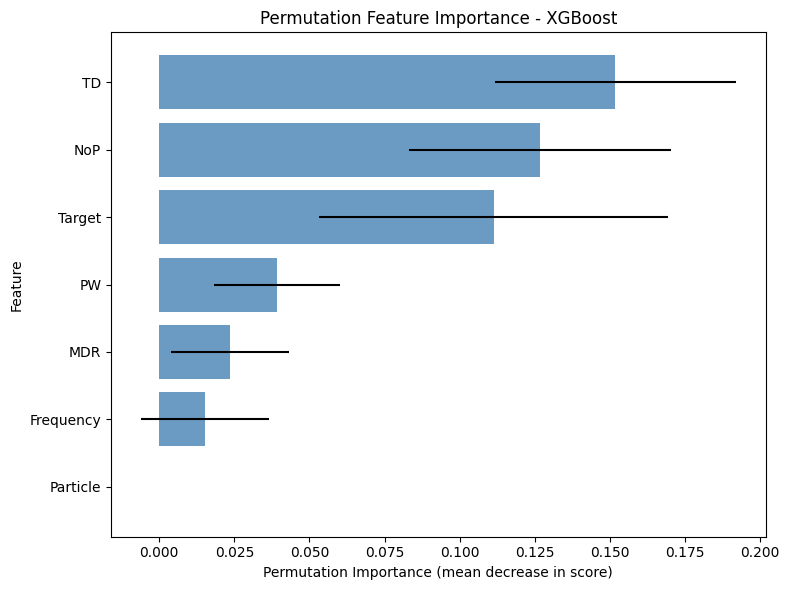

In [43]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model_xgb,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="XGBoost"
)

In [44]:
# Neural Network

In [45]:
"""
from src.models.neural_network import build_mlp
model_nn = build_mlp(input_dim=X_train.shape[1])
"""

'\nfrom src.models.neural_network import build_mlp\nmodel_nn = build_mlp(input_dim=X_train.shape[1])\n'

In [46]:
"""
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train
)


from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_data=(X_test_nn, y_test_nn),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=1
)
"""

"\nfrom sklearn.model_selection import train_test_split\n\nX_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(\n    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train\n)\n\n\nfrom tensorflow.keras.callbacks import EarlyStopping\nes = EarlyStopping(\n    monitor='val_loss',\n    patience=20,\n    restore_best_weights=True\n)\n\nhistory = model_nn.fit(\n    X_train, y_train,\n    validation_data=(X_test_nn, y_test_nn),\n    epochs=200,\n    batch_size=32,\n    callbacks=[es],\n    verbose=1\n)\n"

In [47]:
"""
from src.models.evaluation import evaluate_model_keras
evaluate_model_keras(model_nn, X_test, y_test)
"""

'\nfrom src.models.evaluation import evaluate_model_keras\nevaluate_model_keras(model_nn, X_test, y_test)\n'